# Welcome to Colab!

In [2]:
import pandas as pd

df = pd.read_csv('raw-dataset.csv')
print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 833
Columns: 24


,participantId,ageGroup,educationLevel,aiUseFrequency,selfRatedAI,trustInAI,aiDependence,taskId,category,difficulty,...,initialCorrect,initialConfidence,explanationViewed,finalAnswer,finalCorrect,finalConfidence,answerChanged,confidenceShift,timeSpent,justification
0,0126a2e2-e9e6-4348-831a-ec48b1d88d15,25–34,Postgraduate degree,Weekly,Moderate,3,4,inference-1,Inference,Easy,...,True,3,True,1,True,4,False,1,56,I felt the same way
1,0126a2e2-e9e6-4348-831a-ec48b1d88d15,25–34,Postgraduate degree,Weekly,Moderate,3,4,evaluation-2,Evaluation of Arguments,Difficult,...,True,3,False,0,True,3,False,0,119,"I think both are valid, the explanation I pick..."
2,0126a2e2-e9e6-4348-831a-ec48b1d88d15,25–34,Postgraduate degree,Weekly,Moderate,3,4,deduction-1,Deduction,Easy,...,True,3,False,1,True,3,False,0,51,The logic seemed more right with the answer I ...
3,0126a2e2-e9e6-4348-831a-ec48b1d88d15,25–34,Postgraduate degree,Weekly,Moderate,3,4,probabilistic-1,Probabilistic Reasoning,Moderate,...,True,3,False,1,True,3,False,0,79,I thought similarly compared to the explanation
4,0126a2e2-e9e6-4348-831a-ec48b1d88d15,25–34,Postgraduate degree,Weekly,Moderate,3,4,evidence-1,Evidence Evaluation,Moderate,...,True,3,False,2,True,3,False,0,58,It's not a very scientific statement


In [3]:
# Documented exclusion: this participant's justifications showed clear
# evidence of consulting an external AI chatbot live during the study
# (e.g. copy-pasted dialogue like "give me the survey AI recommendation
# after this"), which is inconsistent with the study design of presenting
# a single predefined AI recommendation. All 7 of their task responses
# are excluded from analysis.
excluded_participant_ids = ['4b9cfb04-e24f-452d-83f1-5fecc0d232bf']

rows_before = len(df)
df = df[~df['participantId'].isin(excluded_participant_ids)].reset_index(drop=True)
rows_after = len(df)

print(f"Excluded {rows_before - rows_after} rows ({len(excluded_participant_ids)} participant(s))")
print(f"Remaining: {rows_after} rows, {df['participantId'].nunique()} participants")

Excluded 7 rows (1 participant(s))
Remaining: 826 rows, 118 participants


In [4]:
tasks_per_participant = df.groupby('participantId').size()

print("Distribution of task count per participant:")
print(tasks_per_participant.value_counts().sort_index())
print()
print("All participants have exactly 7 tasks:", (tasks_per_participant == 7).all())

Distribution of task count per participant:
7    118
Name: count, dtype: int64

All participants have exactly 7 tasks: True


In [5]:
missing = df.isna().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values in the entire dataset.")
else:
    print(missing)

No missing values in the entire dataset.


In [6]:
print("Overall AI condition distribution:")
print(df['aiCondition'].value_counts())
print()
print("As percentages:")
print(df['aiCondition'].value_counts(normalize=True).round(3) * 100)
print()

print("Balance per individual task (rows = task, columns = condition):")
condition_by_task = pd.crosstab(df['taskId'], df['aiCondition'])
print(condition_by_task)
print()

condition_by_task['max_deviation'] = condition_by_task.max(axis=1) - condition_by_task.min(axis=1)
print("Max deviation from perfectly equal split, per task:")
print(condition_by_task['max_deviation'])

Overall AI condition distribution:
aiCondition
partial      279
correct      276
incorrect    271
Name: count, dtype: int64

As percentages:
aiCondition
partial      33.8
correct      33.4
incorrect    32.8
Name: proportion, dtype: float64

Balance per individual task (rows = task, columns = condition):
aiCondition      correct  incorrect  partial
taskId                                      
deduction-1           43         40       35
evaluation-1          35         43       40
evaluation-2          35         43       40
evidence-1            43         40       35
evidence-2            40         35       43
inference-1           40         35       43
probabilistic-1       40         35       43

Max deviation from perfectly equal split, per task:
taskId
deduction-1        8
evaluation-1       8
evaluation-2       8
evidence-1         8
evidence-2         8
inference-1        8
probabilistic-1    8
Name: max_deviation, dtype: int64


In [7]:
print("How many times each position (1-7) appears overall:")
print(df['taskOrder'].value_counts().sort_index())
print()

print("Which task appears at which position (should look shuffled, not fixed):")
order_by_task = pd.crosstab(df['taskId'], df['taskOrder'])
print(order_by_task)

How many times each position (1-7) appears overall:
taskOrder
1    118
2    118
3    118
4    118
5    118
6    118
7    118
Name: count, dtype: int64

Which task appears at which position (should look shuffled, not fixed):
taskOrder         1   2   3   4   5   6   7
taskId                                     
deduction-1      23  18  22  21  12   8  14
evaluation-1     15  20  11  18  22  21  11
evaluation-2     16  17  23   9  19  18  16
evidence-1        7  20  21  20  15  16  19
evidence-2       24  14  11  17  18  13  21
inference-1      22  17  13  15  13  19  19
probabilistic-1  11  12  17  18  19  23  18


In [8]:
# Static study-design reference: which answer (0=A, 1=B, 2=C, 3=D) the AI
# recommends for each task, under each condition. This is fixed by the
# task design (from tasks.js) and is the same for every participant —
# it's not personal data, so it doesn't need to live in Firestore.
TASK_REFERENCE = {
    'inference-1':      {'correct': 1, 'incorrect': 0, 'partial': 3},
    'deduction-1':      {'correct': 1, 'incorrect': 0, 'partial': 3},
    'evaluation-1':     {'correct': 1, 'incorrect': 2, 'partial': 3},
    'probabilistic-1':  {'correct': 1, 'incorrect': 3, 'partial': 2},
    'evidence-1':       {'correct': 2, 'incorrect': 0, 'partial': 3},
    'evaluation-2':     {'correct': 0, 'incorrect': 3, 'partial': 2},
    'evidence-2':       {'correct': 1, 'incorrect': 0, 'partial': 3},
}

df['aiRecommendedAnswer'] = df.apply(
    lambda row: TASK_REFERENCE[row['taskId']][row['aiCondition']], axis=1
)

# Sanity check: for the 'correct' condition, the AI-recommended answer
# should always equal correctAnswer.
mismatch = df[(df['aiCondition'] == 'correct') & (df['aiRecommendedAnswer'] != df['correctAnswer'])]
assert mismatch.empty, f"Reference table mismatch on rows: {mismatch['taskId'].tolist()}"
print("Reference table check passed.")

Reference table check passed.


In [9]:
bool_columns = ['initialCorrect', 'explanationViewed', 'finalCorrect', 'answerChanged']
for col in bool_columns:
    if df[col].dtype == object:
        df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})

print(df[bool_columns].dtypes)

initialCorrect       bool
explanationViewed    bool
finalCorrect         bool
answerChanged        bool
dtype: object


In [10]:
df['followedAI'] = df['finalAnswer'] == df['aiRecommendedAnswer']

df['changedTowardAI'] = (
    df['answerChanged']
    & (df['finalAnswer'] == df['aiRecommendedAnswer'])
    & (df['initialAnswer'] != df['aiRecommendedAnswer'])
)

df['harmfulChange'] = df['answerChanged'] & df['initialCorrect'] & ~df['finalCorrect']
df['beneficialChange'] = df['answerChanged'] & ~df['initialCorrect'] & df['finalCorrect']

df['correctnessChange'] = df['finalCorrect'].astype(int) - df['initialCorrect'].astype(int)

df['confidenceIncrease'] = df['confidenceShift'] > 0
df['confidenceDecrease'] = df['confidenceShift'] < 0

print("Done. New columns:")
print(['followedAI','changedTowardAI','harmfulChange','beneficialChange',
       'correctnessChange','confidenceIncrease','confidenceDecrease'])

Done. New columns:
['followedAI', 'changedTowardAI', 'harmfulChange', 'beneficialChange', 'correctnessChange', 'confidenceIncrease', 'confidenceDecrease']


In [11]:
df['failureToInspectExplanation'] = ~df['explanationViewed']

df['confidenceIncreaseAfterWrongAI'] = (
    df['confidenceIncrease']
    & df['aiCondition'].isin(['incorrect', 'partial'])
    & df['followedAI']
)

print("Done.")

Done.


In [12]:
df['strongOutsourcingEvidence'] = (
    df['initialCorrect']
    & (df['aiCondition'] == 'incorrect')
    & df['followedAI']
    & ~df['explanationViewed']
    & df['confidenceIncrease']
)

print("Cases matching the strong outsourcing evidence pattern:", df['strongOutsourcingEvidence'].sum())

Cases matching the strong outsourcing evidence pattern: 5


In [13]:
def classify_pattern(row):
    if row['aiCondition'] == 'correct' and row['followedAI']:
        return 'correct AI accepted'
    if row['aiCondition'] == 'incorrect' and row['followedAI']:
        return 'incorrect AI accepted'
    if row['aiCondition'] == 'partial' and row['followedAI']:
        return 'partial AI accepted'
    if row['aiCondition'] in ('incorrect', 'partial') and not row['followedAI']:
        return 'incorrect/partial AI rejected'
    if row['aiCondition'] == 'correct' and not row['followedAI'] and not row['finalCorrect']:
        return 'correct AI rejected, still wrong'
    return 'other'

df['behaviourPattern'] = df.apply(classify_pattern, axis=1)
print(df['behaviourPattern'].value_counts())

behaviourPattern
incorrect/partial AI rejected       410
correct AI accepted                 200
partial AI accepted                  84
correct AI rejected, still wrong     76
incorrect AI accepted                56
Name: count, dtype: int64


In [14]:
df['overreliance'] = (
    df['followedAI']
    & df['aiCondition'].isin(['incorrect', 'partial'])
    & ~df['explanationViewed']
    & ~df['finalCorrect']
)

df['engagedWithExplanation'] = df['explanationViewed'] & df['followedAI']

df['resistedFlawedAI'] = df['aiCondition'].isin(['incorrect', 'partial']) & df['finalCorrect']

df['appropriateReliance'] = df['followedAI'] & (df['aiCondition'] == 'correct') & df['finalCorrect']

df['highConfidenceWrongFinal'] = (df['finalConfidence'] >= 4) & ~df['finalCorrect']

df['justificationLength'] = df['justification'].fillna('').apply(lambda s: len(str(s).split()))

print("Done. Overreliance cases:", df['overreliance'].sum())
print("Resisted flawed AI cases:", df['resistedFlawedAI'].sum())

Done. Overreliance cases: 119
Resisted flawed AI cases: 281


In [15]:
checks = []

checks.append(('initialCorrect == (initialAnswer==correctAnswer)',
    (df['initialCorrect'] == (df['initialAnswer'] == df['correctAnswer'])).all()))

checks.append(('finalCorrect == (finalAnswer==correctAnswer)',
    (df['finalCorrect'] == (df['finalAnswer'] == df['correctAnswer'])).all()))

checks.append(('answerChanged == (initialAnswer != finalAnswer)',
    (df['answerChanged'] == (df['initialAnswer'] != df['finalAnswer'])).all()))

checks.append(('followedAI == (finalAnswer==aiRecommendedAnswer)',
    (df['followedAI'] == (df['finalAnswer'] == df['aiRecommendedAnswer'])).all()))

expected = df['answerChanged'] & df['followedAI'] & (df['initialAnswer'] != df['aiRecommendedAnswer'])
checks.append(('changedTowardAI logic', (df['changedTowardAI'] == expected).all()))

expected = df['answerChanged'] & df['initialCorrect'] & ~df['finalCorrect']
checks.append(('harmfulChange logic', (df['harmfulChange'] == expected).all()))

expected = df['answerChanged'] & ~df['initialCorrect'] & df['finalCorrect']
checks.append(('beneficialChange logic', (df['beneficialChange'] == expected).all()))

expected = df['finalCorrect'].astype(int) - df['initialCorrect'].astype(int)
checks.append(('correctnessChange logic', (df['correctnessChange'] == expected).all()))

expected = df['finalConfidence'] - df['initialConfidence']
checks.append(('confidenceShift == finalConfidence-initialConfidence', (df['confidenceShift'] == expected).all()))

checks.append(('confidenceIncrease logic', (df['confidenceIncrease'] == (df['confidenceShift'] > 0)).all()))
checks.append(('confidenceDecrease logic', (df['confidenceDecrease'] == (df['confidenceShift'] < 0)).all()))
checks.append(('failureToInspectExplanation == ~explanationViewed', (df['failureToInspectExplanation'] == ~df['explanationViewed']).all()))

expected = df['followedAI'] & df['aiCondition'].isin(['incorrect','partial']) & ~df['explanationViewed'] & ~df['finalCorrect']
checks.append(('overreliance logic', (df['overreliance'] == expected).all()))

expected = df['aiCondition'].isin(['incorrect','partial']) & df['finalCorrect']
checks.append(('resistedFlawedAI logic', (df['resistedFlawedAI'] == expected).all()))

expected = df['followedAI'] & (df['aiCondition']=='correct') & df['finalCorrect']
checks.append(('appropriateReliance logic', (df['appropriateReliance'] == expected).all()))

expected = (df['finalConfidence']>=4) & ~df['finalCorrect']
checks.append(('highConfidenceWrongFinal logic', (df['highConfidenceWrongFinal'] == expected).all()))

expected = df['initialCorrect'] & (df['aiCondition']=='incorrect') & df['followedAI'] & ~df['explanationViewed'] & df['confidenceIncrease']
checks.append(('strongOutsourcingEvidence logic', (df['strongOutsourcingEvidence'] == expected).all()))

for name, result in checks:
    status = "OK" if result else "!!! ERROR !!!"
    print(f"{status:15} {name}")

OK              initialCorrect == (initialAnswer==correctAnswer)
OK              finalCorrect == (finalAnswer==correctAnswer)
OK              answerChanged == (initialAnswer != finalAnswer)
OK              followedAI == (finalAnswer==aiRecommendedAnswer)
OK              changedTowardAI logic
OK              harmfulChange logic
OK              beneficialChange logic
OK              correctnessChange logic
OK              confidenceShift == finalConfidence-initialConfidence
OK              confidenceIncrease logic
OK              confidenceDecrease logic
OK              failureToInspectExplanation == ~explanationViewed
OK              overreliance logic
OK              resistedFlawedAI logic
OK              appropriateReliance logic
OK              highConfidenceWrongFinal logic
OK              strongOutsourcingEvidence logic


In [16]:
print("timeSpent (seconds) — summary:")
print(df['timeSpent'].describe())
print()

print("Rows with timeSpent > 600s (10+ min on a single task):", (df['timeSpent'] > 600).sum())
print("Rows with timeSpent > 1800s (30+ min):", (df['timeSpent'] > 1800).sum())
print()

print("Duplicate participantId+taskId rows:", df.duplicated(subset=['participantId','taskId']).sum())

timeSpent (seconds) — summary:
count      826.000000
mean       148.730024
std        697.780178
min          5.000000
25%         56.000000
50%         84.000000
75%        135.000000
max      18584.000000
Name: timeSpent, dtype: float64

Rows with timeSpent > 600s (10+ min on a single task): 12
Rows with timeSpent > 1800s (30+ min): 4

Duplicate participantId+taskId rows: 0


In [18]:
justification_scores = pd.read_csv('justification-scores.csv')
print("Loaded:", len(justification_scores), "rows")
print("Score distribution:")
print(justification_scores['justificationScore'].value_counts().sort_index())

Loaded: 826 rows
Score distribution:
justificationScore
0.0    245
1.0    228
2.0    246
3.0    107
Name: count, dtype: int64


In [19]:
df = df.merge(
    justification_scores[['participantId', 'taskId', 'justificationScore']],
    on=['participantId', 'taskId'],
    how='left'
)

print("Rows after merge:", len(df))
print("Rows with a justificationScore:", df['justificationScore'].notna().sum())

Rows after merge: 826
Rows with a justificationScore: 826


In [20]:
low_quality_count = df.groupby('participantId')['justificationScore'].apply(lambda s: (s == 0).sum())
suspicious = low_quality_count[low_quality_count >= 5]

print("Participants with 5+ out of 7 tasks scored 0 (no meaningful justification):", len(suspicious))
print()
print("Participants with all 7 tasks scored 0:", (low_quality_count == 7).sum())

Participants with 5+ out of 7 tasks scored 0 (no meaningful justification): 27

Participants with all 7 tasks scored 0: 13


In [21]:
# Flag participants for sensitivity analysis, rather than deleting them —
# they still have valid task responses, just weak/absent justifications.
low_effort_ids = low_quality_count[low_quality_count >= 5].index
df['lowEngagementParticipant'] = df['participantId'].isin(low_effort_ids)

# Same approach for the extreme timeSpent outliers — flag, don't delete.
df['timeOutlier'] = df['timeSpent'] > 600

print("Rows flagged as low engagement:", df['lowEngagementParticipant'].sum())
print("Rows flagged as time outlier:", df['timeOutlier'].sum())

Rows flagged as low engagement: 189
Rows flagged as time outlier: 12


In [22]:
print("Age group:")
print(df.drop_duplicates('participantId')['ageGroup'].value_counts())
print()

print("Education level:")
print(df.drop_duplicates('participantId')['educationLevel'].value_counts())
print()

print("AI use frequency:")
print(df.drop_duplicates('participantId')['aiUseFrequency'].value_counts())
print()

print("Self-rated AI literacy:")
print(df.drop_duplicates('participantId')['selfRatedAI'].value_counts())
print()

print("Trust in AI (1-5 scale) — summary:")
print(df.drop_duplicates('participantId')['trustInAI'].describe())
print()

print("AI dependence (1-5 scale) — summary:")
print(df.drop_duplicates('participantId')['aiDependence'].describe())

Age group:
ageGroup
18–24    49
25–34    46
35–44    15
45–54     6
55+       1
18～24     1
Name: count, dtype: int64

Education level:
educationLevel
Undergraduate degree     47
Postgraduate degree      45
College or equivalent    12
Secondary education       8
Other                     2
研究生学位                     1
Lisans derecesi           1
Pós-graduação             1
大学卒業または同等の資格              1
Name: count, dtype: int64

AI use frequency:
aiUseFrequency
Daily                60
Weekly               32
Monthly              13
Less than monthly     6
Never                 3
每日报                   1
Aylık                 1
Diário                1
毎日                    1
Name: count, dtype: int64

Self-rated AI literacy:
selfRatedAI
Moderate     56
High         43
Very high     9
Low           3
Very low      3
中等            1
Tılımlı       1
Alto          1
高い            1
Name: count, dtype: int64

Trust in AI (1-5 scale) — summary:
count    118.000000
mean       3.194915
std        0

/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 65374 (\N{FULLWIDTH TILDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 30740 (\N{CJK UNIFIED IDEOGRAPH-7814}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 31350 (\N{CJK UNIFIED IDEOGRAPH-7A76}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_821/311633674.py:18: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) De

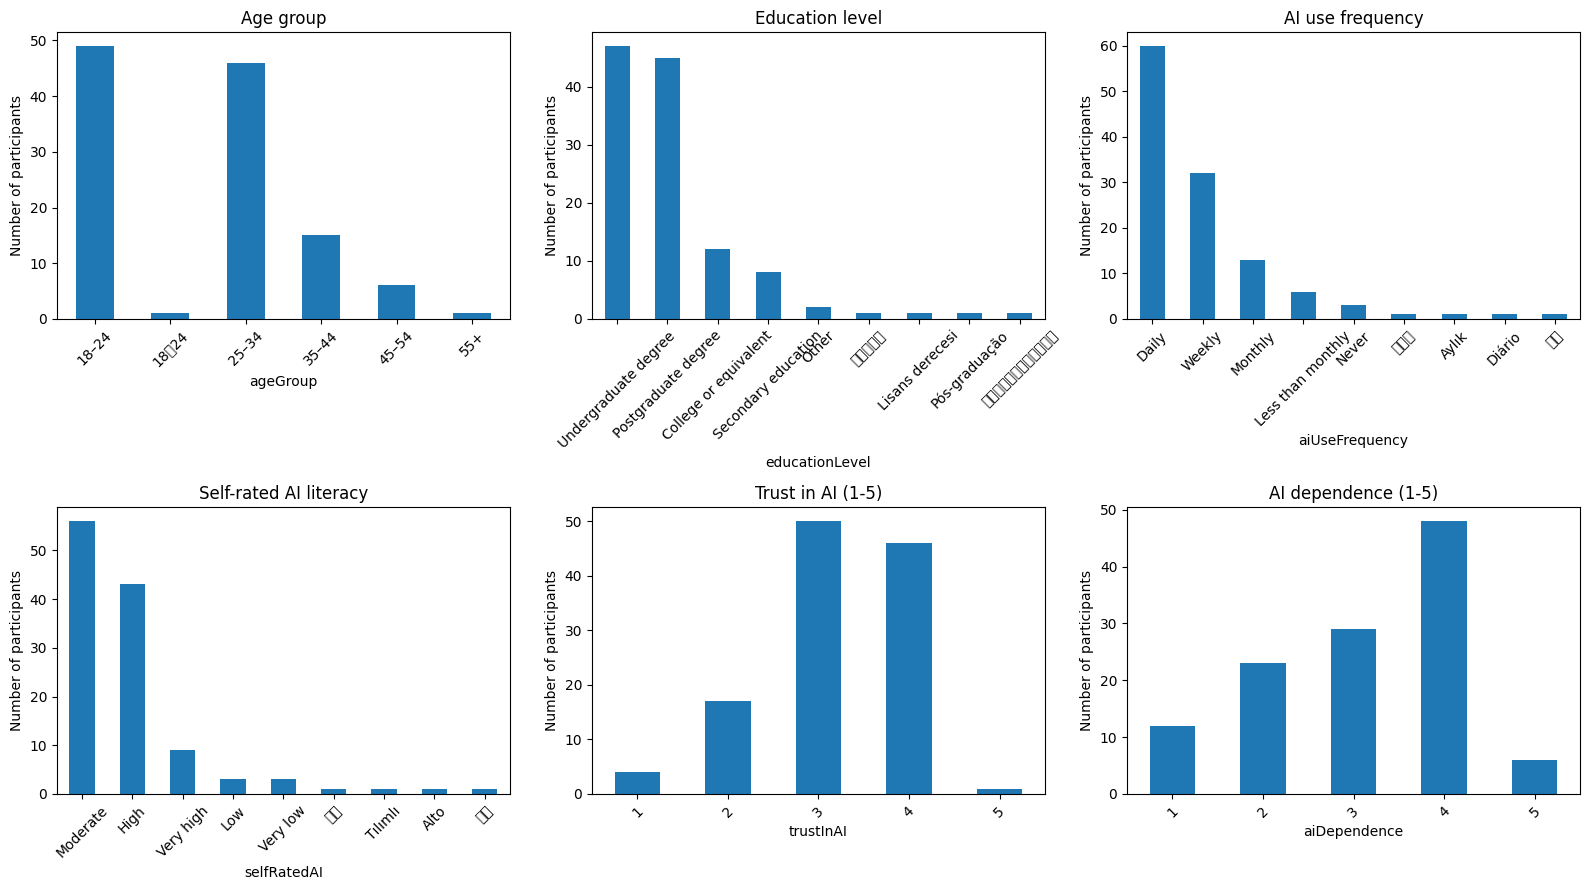

In [23]:
import matplotlib.pyplot as plt

participants = df.drop_duplicates('participantId')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

participants['ageGroup'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], title='Age group')
participants['educationLevel'].value_counts().plot(kind='bar', ax=axes[0,1], title='Education level')
participants['aiUseFrequency'].value_counts().plot(kind='bar', ax=axes[0,2], title='AI use frequency')
participants['selfRatedAI'].value_counts().plot(kind='bar', ax=axes[1,0], title='Self-rated AI literacy')
participants['trustInAI'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], title='Trust in AI (1-5)')
participants['aiDependence'].value_counts().sort_index().plot(kind='bar', ax=axes[1,2], title='AI dependence (1-5)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Number of participants')

plt.tight_layout()
plt.show()

In [24]:
initial_accuracy = df.groupby('taskId')['initialCorrect'].mean().sort_values()
print("Initial accuracy rate per task (before seeing AI):")
print((initial_accuracy * 100).round(1))

Initial accuracy rate per task (before seeing AI):
taskId
evidence-2         39.0
probabilistic-1    43.2
deduction-1        55.1
evaluation-1       62.7
evidence-1         63.6
evaluation-2       66.1
inference-1        79.7
Name: initialCorrect, dtype: float64


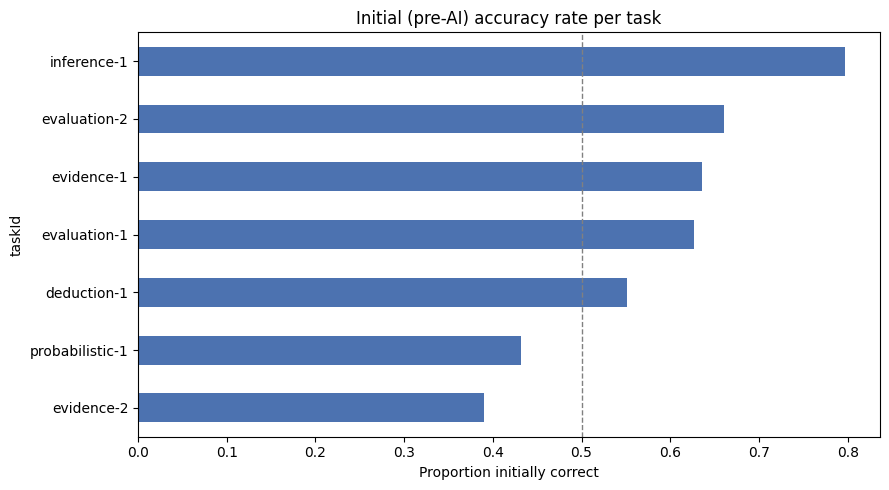

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
initial_accuracy.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Proportion initially correct')
ax.set_title('Initial (pre-AI) accuracy rate per task')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [26]:
baseline_confidence = df.groupby('aiCondition')['initialConfidence'].agg(['mean', 'std', 'count'])
print(baseline_confidence.round(2))

             mean   std  count
aiCondition                   
correct      4.12  0.87    276
incorrect    4.18  0.79    271
partial      4.12  0.84    279


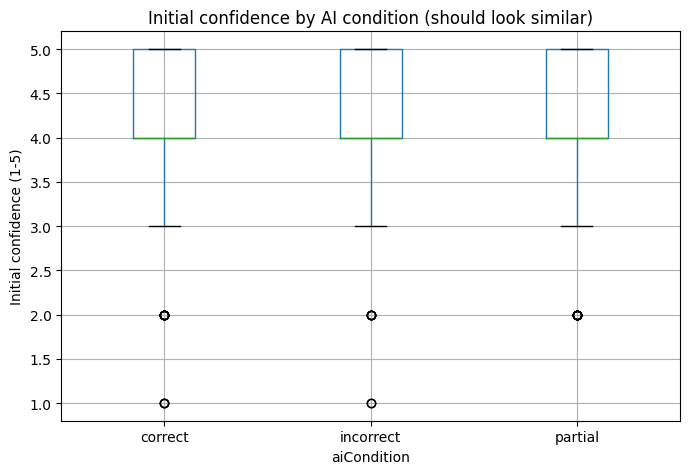

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='initialConfidence', by='aiCondition', ax=ax)
ax.set_title('Initial confidence by AI condition (should look similar)')
ax.set_ylabel('Initial confidence (1-5)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [28]:
primary_vars = ['changedTowardAI', 'harmfulChange', 'overreliance', 'resistedFlawedAI', 'strongOutsourcingEvidence']

print("=== Overview across all 826 observations ===")
for var in primary_vars:
    count = df[var].sum()
    pct = df[var].mean() * 100
    print(f"{var:28} {count:4} cases  ({pct:.1f}%)")

print()
print("=== Confidence shift — overall ===")
print(df['confidenceShift'].describe().round(2))

=== Overview across all 826 observations ===
changedTowardAI               117 cases  (14.2%)
harmfulChange                  64 cases  (7.7%)
overreliance                  119 cases  (14.4%)
resistedFlawedAI              281 cases  (34.0%)
strongOutsourcingEvidence       5 cases  (0.6%)

=== Confidence shift — overall ===
count    826.00
mean       0.09
std        0.71
min       -3.00
25%        0.00
50%        0.00
75%        0.00
max        3.00
Name: confidenceShift, dtype: float64


In [29]:
flawed_rows = df[df['aiCondition'].isin(['incorrect', 'partial'])]
print(f"Rows with a flawed (incorrect/partial) recommendation: {len(flawed_rows)}")
print(f"Of those, resisted (stayed/reached correct): {flawed_rows['resistedFlawedAI'].sum()} ({flawed_rows['resistedFlawedAI'].mean()*100:.1f}%)")
print(f"Of those, overreliance cases: {flawed_rows['overreliance'].sum()} ({flawed_rows['overreliance'].mean()*100:.1f}%)")
print(f"Of those, harmfulChange cases: {flawed_rows['harmfulChange'].sum()} ({flawed_rows['harmfulChange'].mean()*100:.1f}%)")

Rows with a flawed (incorrect/partial) recommendation: 550
Of those, resisted (stayed/reached correct): 281 (51.1%)
Of those, overreliance cases: 119 (21.6%)
Of those, harmfulChange cases: 56 (10.2%)


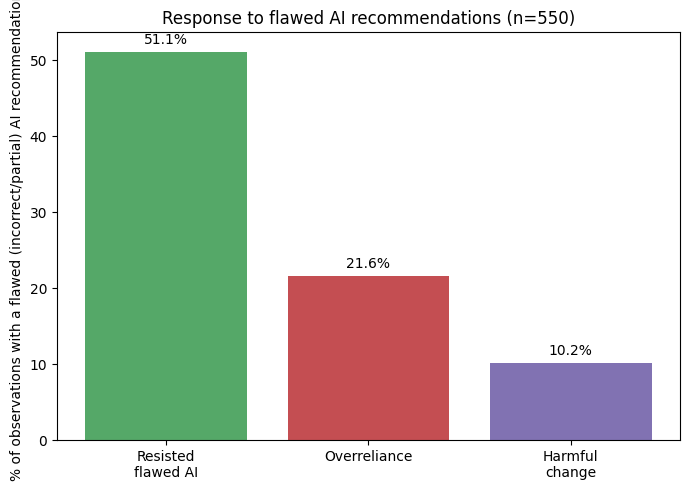

In [30]:
import matplotlib.pyplot as plt

labels = ['Resisted\nflawed AI', 'Overreliance', 'Harmful\nchange']
values = [
    flawed_rows['resistedFlawedAI'].mean()*100,
    flawed_rows['overreliance'].mean()*100,
    flawed_rows['harmfulChange'].mean()*100
]

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(labels, values, color=['#55A868','#C44E52','#8172B2'])
ax.set_ylabel('% of observations with a flawed (incorrect/partial) AI recommendation')
ax.set_title('Response to flawed AI recommendations (n=550)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}%', ha='center')
plt.tight_layout()
plt.show()

In [31]:
confidence_by_condition = df.groupby('aiCondition')['confidenceShift'].agg(['mean', 'std', 'count']).round(2)
print(confidence_by_condition)
print()

print("Confidence shift when AI was followed vs not, by condition:")
print(df.groupby(['aiCondition', 'followedAI'])['confidenceShift'].mean().round(2))

             mean   std  count
aiCondition                   
correct      0.18  0.74    276
incorrect    0.00  0.70    271
partial      0.10  0.70    279

Confidence shift when AI was followed vs not, by condition:
aiCondition  followedAI
correct      False        -0.01
             True          0.26
incorrect    False        -0.05
             True          0.20
partial      False        -0.05
             True          0.44
Name: confidenceShift, dtype: float64


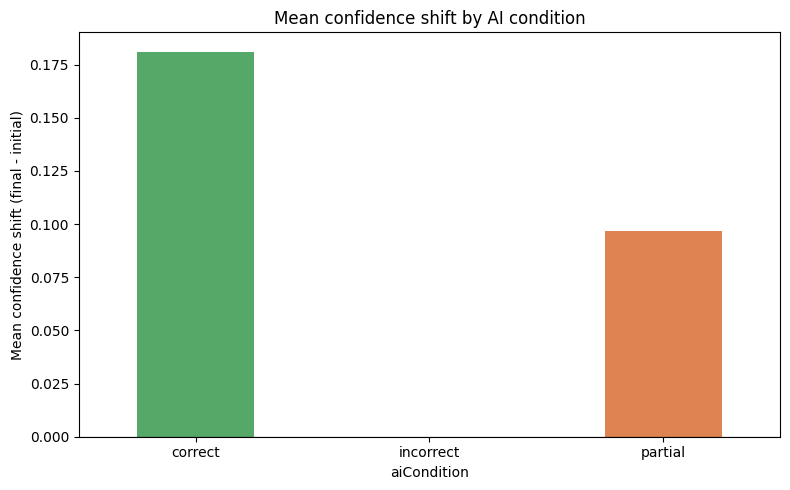

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
df.groupby('aiCondition')['confidenceShift'].mean().plot(kind='bar', ax=ax, color=['#55A868','#C44E52','#DD8452'])
ax.set_ylabel('Mean confidence shift (final - initial)')
ax.set_title('Mean confidence shift by AI condition')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

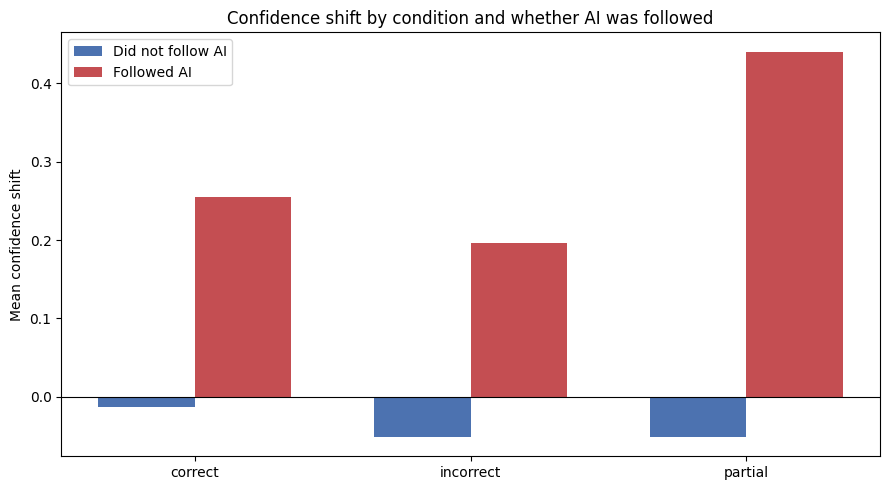

In [33]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.groupby(['aiCondition', 'followedAI'])['confidenceShift'].mean().unstack()
pivot = pivot.reindex(['correct', 'incorrect', 'partial'])

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(pivot.index))
width = 0.35

ax.bar(x - width/2, pivot[False], width, label='Did not follow AI', color='#4C72B0')
ax.bar(x + width/2, pivot[True], width, label='Followed AI', color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Mean confidence shift')
ax.set_title('Confidence shift by condition and whether AI was followed')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
print("Mean justificationScore by AI condition:")
print(df.groupby('aiCondition')['justificationScore'].mean().round(2))
print()

print("Mean justificationScore: overreliance vs not:")
print(df.groupby('overreliance')['justificationScore'].mean().round(2))
print()

print("Mean justificationScore: followedAI vs not (within flawed conditions only):")
print(flawed_rows.groupby('followedAI')['justificationScore'].mean().round(2))

Mean justificationScore by AI condition:
aiCondition
correct      1.19
incorrect    1.33
partial      1.27
Name: justificationScore, dtype: float64

Mean justificationScore: overreliance vs not:
overreliance
False    1.30
True     1.01
Name: justificationScore, dtype: float64

Mean justificationScore: followedAI vs not (within flawed conditions only):
followedAI
False    1.38
True     1.06
Name: justificationScore, dtype: float64


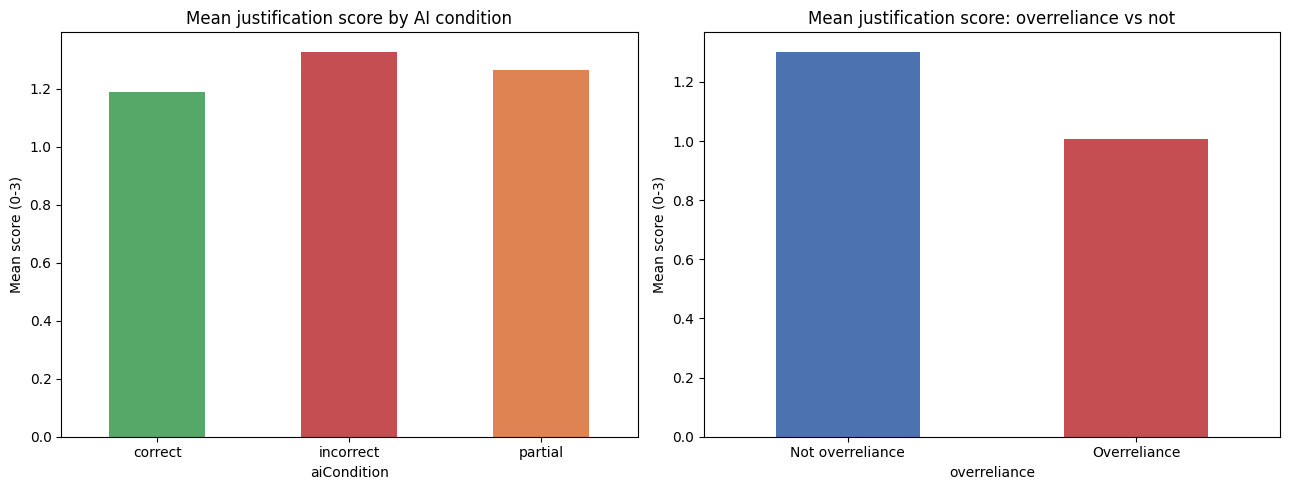

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,5))

df.groupby('aiCondition')['justificationScore'].mean().plot(kind='bar', ax=axes[0], color=['#55A868','#C44E52','#DD8452'])
axes[0].set_title('Mean justification score by AI condition')
axes[0].set_ylabel('Mean score (0-3)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('overreliance')['justificationScore'].mean().plot(kind='bar', ax=axes[1], color=['#4C72B0','#C44E52'])
axes[1].set_title('Mean justification score: overreliance vs not')
axes[1].set_xticklabels(['Not overreliance', 'Overreliance'], rotation=0)
axes[1].set_ylabel('Mean score (0-3)')

plt.tight_layout()
plt.show()

In [36]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['aiCondition'], df['followedAI'])
print(contingency)
print()

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square = {chi2:.2f}, df = {dof}, p-value = {p:.10f}")

followedAI   False  True 
aiCondition              
correct         76    200
incorrect      215     56
partial        195     84

Chi-square = 172.75, df = 2, p-value = 0.0000000000


In [37]:
# For each participant, compute their followedAI rate separately for
# each condition they encountered (repeated-measures structure: same
# participant contributes to all 3 conditions, just via different tasks).
participant_rates = df.groupby(['participantId', 'aiCondition'])['followedAI'].mean().unstack()
print(participant_rates.head())
print()
print("Participants with data in all 3 conditions:", participant_rates.dropna().shape[0], "out of", len(participant_rates))

aiCondition                            correct  incorrect   partial
participantId                                                      
0126a2e2-e9e6-4348-831a-ec48b1d88d15  1.000000        0.0  0.000000
054ec129-10f8-4d62-8930-ad9cbc55f555  1.000000        0.0  0.000000
06c78688-6d84-4f46-8660-fb19c804f41e  0.666667        0.0  0.000000
06e940a4-6576-42cd-9ab6-e93cf6c569f4  1.000000        1.0  0.333333
0f90d135-f96c-443d-b693-f9e2e38f78de  1.000000        0.0  0.000000

Participants with data in all 3 conditions: 118 out of 118


In [38]:
from scipy.stats import friedmanchisquare

friedman_stat, friedman_p = friedmanchisquare(
    participant_rates['correct'],
    participant_rates['incorrect'],
    participant_rates['partial']
)
print(f"Friedman chi-square = {friedman_stat:.2f}, p-value = {friedman_p:.10f}")
print()

print("Mean followedAI rate per participant, by condition:")
print(participant_rates.mean().round(3))

Friedman chi-square = 95.44, p-value = 0.0000000000

Mean followedAI rate per participant, by condition:
aiCondition
correct      0.720
incorrect    0.206
partial      0.294
dtype: float64


In [39]:
from scipy.stats import wilcoxon

pairs = [('correct', 'incorrect'), ('correct', 'partial'), ('incorrect', 'partial')]

for a, b in pairs:
    stat, p = wilcoxon(participant_rates[a], participant_rates[b])
    print(f"{a} vs {b}: W = {stat:.1f}, p = {p:.8f}")

correct vs incorrect: W = 169.0, p = 0.00000000
correct vs partial: W = 320.5, p = 0.00000000
incorrect vs partial: W = 1130.0, p = 0.03922904


In [50]:
import numpy as np

# Kendall's W for the Friedman test: W = chi-square / (n * (k-1))
n_participants = len(participant_rates)
k_conditions = 3
kendalls_w = friedman_stat / (n_participants * (k_conditions - 1))
print(f"Kendall's W = {kendalls_w:.3f}  (n={n_participants}, k={k_conditions})")
print("Interpretation guide: ~0.1 small, ~0.3 medium, ~0.5+ large")
print()

# Matched-pairs rank-biserial correlation for each Wilcoxon comparison:
# r = 1 - (2*T) / (n*(n+1)), where T is the smaller rank sum (the
# statistic scipy's wilcoxon returns by default) and n is the number
# of non-zero differences in that pair.
def rank_biserial(a, b):
    diff = a - b
    n_nonzero = (diff != 0).sum()
    stat, p = wilcoxon(a, b)
    r = 1 - (2 * stat) / (n_nonzero * (n_nonzero + 1))
    return stat, p, r, n_nonzero

for cond_a, cond_b in pairs:
    stat, p, r, n_nz = rank_biserial(participant_rates[cond_a], participant_rates[cond_b])
    print(f"{cond_a} vs {cond_b}: W={stat:.1f}, p={p:.8f}, rank-biserial r={r:.3f} (n_nonzero={n_nz})")

Kendall's W = 0.404  (n=118, k=3)
Interpretation guide: ~0.1 small, ~0.3 medium, ~0.5+ large

correct vs incorrect: W=169.0, p=0.00000000, rank-biserial r=0.968 (n_nonzero=102)
correct vs partial: W=320.5, p=0.00000000, rank-biserial r=0.931 (n_nonzero=96)
incorrect vs partial: W=1130.0, p=0.03922904, rank-biserial r=0.633 (n_nonzero=78)


In [40]:
# Sensitivity check: same Friedman test, excluding low-engagement participants
df_clean = df[~df['lowEngagementParticipant']]
print(f"Participants remaining: {df_clean['participantId'].nunique()} (excluded {df['participantId'].nunique() - df_clean['participantId'].nunique()})")
print()

participant_rates_clean = df_clean.groupby(['participantId', 'aiCondition'])['followedAI'].mean().unstack()

from scipy.stats import friedmanchisquare
friedman_stat_clean, friedman_p_clean = friedmanchisquare(
    participant_rates_clean['correct'],
    participant_rates_clean['incorrect'],
    participant_rates_clean['partial']
)
print(f"Friedman chi-square (excl. low engagement) = {friedman_stat_clean:.2f}, p-value = {friedman_p_clean:.10f}")
print()
print("Mean followedAI rate per participant, by condition (excl. low engagement):")
print(participant_rates_clean.mean().round(3))

Participants remaining: 91 (excluded 27)

Friedman chi-square (excl. low engagement) = 76.90, p-value = 0.0000000000

Mean followedAI rate per participant, by condition (excl. low engagement):
aiCondition
correct      0.747
incorrect    0.211
partial      0.289
dtype: float64


In [41]:
# Sensitivity check #2: same Friedman test, excluding time outlier rows
df_no_outliers = df[~df['timeOutlier']]
print(f"Rows remaining: {len(df_no_outliers)} (excluded {len(df) - len(df_no_outliers)})")
print(f"Participants remaining: {df_no_outliers['participantId'].nunique()}")
print()

participant_rates_no_outliers = df_no_outliers.groupby(['participantId', 'aiCondition'])['followedAI'].mean()
participant_rates_no_outliers = participant_rates_no_outliers.unstack()

# Some participants might now be missing a condition entirely if their
# only task in that condition was the outlier row — check for that first.
missing = participant_rates_no_outliers[participant_rates_no_outliers.isna().any(axis=1)]
print(f"Participants now missing a full condition: {len(missing)}")

participant_rates_no_outliers_complete = participant_rates_no_outliers.dropna()

from scipy.stats import friedmanchisquare
friedman_stat_2, friedman_p_2 = friedmanchisquare(
    participant_rates_no_outliers_complete['correct'],
    participant_rates_no_outliers_complete['incorrect'],
    participant_rates_no_outliers_complete['partial']
)
print(f"Friedman chi-square (excl. time outliers) = {friedman_stat_2:.2f}, p-value = {friedman_p_2:.10f}")
print()
print("Mean followedAI rate per participant, by condition (excl. time outliers):")
print(participant_rates_no_outliers_complete.mean().round(3))

Rows remaining: 814 (excluded 12)
Participants remaining: 118

Participants now missing a full condition: 0
Friedman chi-square (excl. time outliers) = 89.88, p-value = 0.0000000000

Mean followedAI rate per participant, by condition (excl. time outliers):
aiCondition
correct      0.715
incorrect    0.208
partial      0.292
dtype: float64


In [42]:
participant_summary = df.groupby('participantId').agg(
    followedAI_rate=('followedAI', 'mean'),
    aiUseFrequency=('aiUseFrequency', 'first'),
    selfRatedAI=('selfRatedAI', 'first'),
    trustInAI=('trustInAI', 'first'),
    aiDependence=('aiDependence', 'first'),
).reset_index()

# Overreliance rate only makes sense within flawed (incorrect/partial) trials
flawed_only = df[df['aiCondition'].isin(['incorrect', 'partial'])]
overreliance_rate = flawed_only.groupby('participantId')['overreliance'].mean().rename('overreliance_rate')

participant_summary = participant_summary.merge(overreliance_rate, on='participantId', how='left')

print(participant_summary.head())
print()
print(participant_summary.describe(include='all'))

                          participantId  followedAI_rate aiUseFrequency  \
0  0126a2e2-e9e6-4348-831a-ec48b1d88d15         0.428571         Weekly   
1  054ec129-10f8-4d62-8930-ad9cbc55f555         0.428571          Daily   
2  06c78688-6d84-4f46-8660-fb19c804f41e         0.285714          Daily   
3  06e940a4-6576-42cd-9ab6-e93cf6c569f4         0.714286        Monthly   
4  0f90d135-f96c-443d-b693-f9e2e38f78de         0.285714        Monthly   

  selfRatedAI  trustInAI  aiDependence  overreliance_rate  
0    Moderate          3             4                0.0  
1        High          4             4                0.0  
2    Moderate          2             3                0.0  
3         Low          4             3                0.6  
4        High          1             2                0.0  

                               participantId  followedAI_rate aiUseFrequency  \
count                                    118       118.000000            118   
unique                      

In [43]:
print("Unique values in aiUseFrequency:")
print(df['aiUseFrequency'].value_counts())
print()
print("Unique values in selfRatedAI:")
print(df['selfRatedAI'].value_counts())

Unique values in aiUseFrequency:
aiUseFrequency
Daily                420
Weekly               224
Monthly               91
Less than monthly     42
Never                 21
每日报                    7
Aylık                  7
Diário                 7
毎日                     7
Name: count, dtype: int64

Unique values in selfRatedAI:
selfRatedAI
Moderate     392
High         301
Very high     63
Low           21
Very low      21
中等             7
Tılımlı        7
Alto           7
高い             7
Name: count, dtype: int64


In [44]:
# Fix browser-translation artifacts: a few participants' browsers
# auto-translated the page before submission, capturing translated
# dropdown text instead of the original English value. Clear
# translations are recoded; "Tılımlı" has no standard meaning and is
# left as unknown rather than guessed.
translation_map_freq = {
    '每日报': 'Daily',
    'Diário': 'Daily',
    '毎日': 'Daily',
    'Aylık': 'Monthly',
}
translation_map_literacy = {
    '中等': 'Moderate',
    'Alto': 'High',
    '高い': 'High',
    'Tılımlı': pd.NA,  # meaning unclear, left as unknown rather than guessed
}

df['aiUseFrequency'] = df['aiUseFrequency'].replace(translation_map_freq)
df['selfRatedAI'] = df['selfRatedAI'].replace(translation_map_literacy)

print("aiUseFrequency after cleanup:")
print(df['aiUseFrequency'].value_counts(dropna=False))
print()
print("selfRatedAI after cleanup:")
print(df['selfRatedAI'].value_counts(dropna=False))

aiUseFrequency after cleanup:
aiUseFrequency
Daily                441
Weekly               224
Monthly               98
Less than monthly     42
Never                 21
Name: count, dtype: int64

selfRatedAI after cleanup:
selfRatedAI
Moderate     399
High         315
Very high     63
Low           21
Very low      21
<NA>           7
Name: count, dtype: int64


In [45]:
participant_summary = df.groupby('participantId').agg(
    followedAI_rate=('followedAI', 'mean'),
    aiUseFrequency=('aiUseFrequency', 'first'),
    selfRatedAI=('selfRatedAI', 'first'),
    trustInAI=('trustInAI', 'first'),
    aiDependence=('aiDependence', 'first'),
).reset_index()

flawed_only = df[df['aiCondition'].isin(['incorrect', 'partial'])]
overreliance_rate = flawed_only.groupby('participantId')['overreliance'].mean().rename('overreliance_rate')
participant_summary = participant_summary.merge(overreliance_rate, on='participantId', how='left')

print(participant_summary.shape)
print(participant_summary['selfRatedAI'].value_counts(dropna=False))

(118, 7)
selfRatedAI
Moderate     57
High         45
Very high     9
Low           3
Very low      3
None          1
Name: count, dtype: int64


In [46]:
print("Mean overreliance rate by AI use frequency:")
print(participant_summary.groupby('aiUseFrequency')['overreliance_rate'].agg(['mean', 'count']).round(3))
print()

print("Mean overreliance rate by self-rated AI literacy:")
print(participant_summary.groupby('selfRatedAI')['overreliance_rate'].agg(['mean', 'count']).round(3))

Mean overreliance rate by AI use frequency:
                    mean  count
aiUseFrequency                 
Daily              0.216     63
Less than monthly  0.208      6
Monthly            0.132     14
Never              0.200      3
Weekly             0.241     32

Mean overreliance rate by self-rated AI literacy:
              mean  count
selfRatedAI              
High         0.212     45
Low          0.400      3
Moderate     0.203     57
Very high    0.233      9
Very low     0.067      3


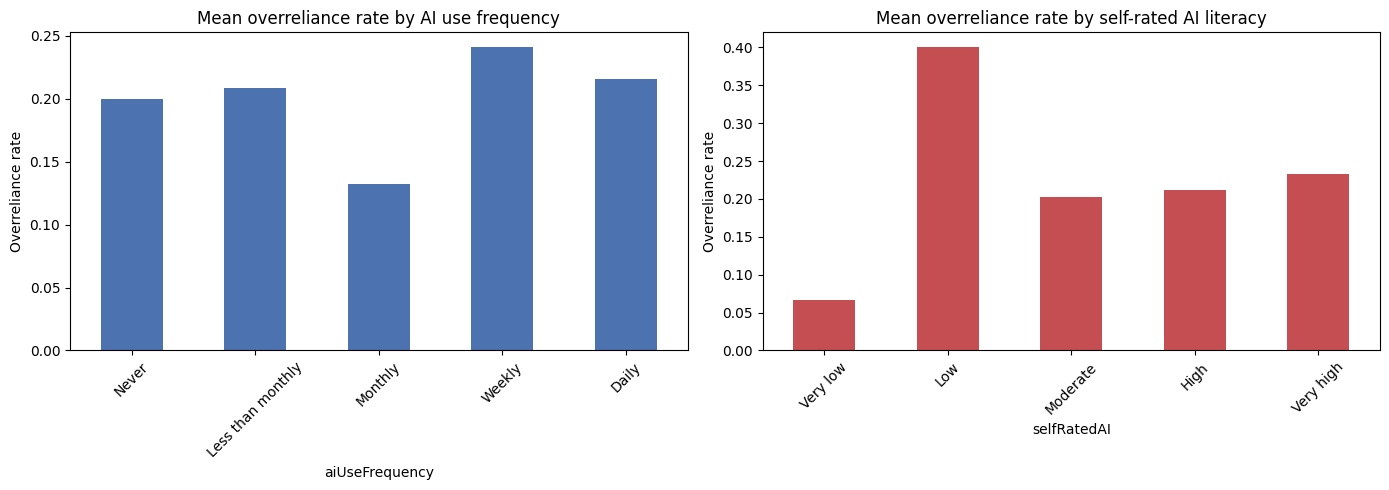

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

order_freq = ['Never', 'Less than monthly', 'Monthly', 'Weekly', 'Daily']
participant_summary.groupby('aiUseFrequency')['overreliance_rate'].mean().reindex(order_freq).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Mean overreliance rate by AI use frequency')
axes[0].set_ylabel('Overreliance rate')
axes[0].tick_params(axis='x', rotation=45)

order_lit = ['Very low', 'Low', 'Moderate', 'High', 'Very high']
participant_summary.groupby('selfRatedAI')['overreliance_rate'].mean().reindex(order_lit).plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Mean overreliance rate by self-rated AI literacy')
axes[1].set_ylabel('Overreliance rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [48]:
print("Correlation between overreliance_rate and trustInAI / aiDependence:")
print(participant_summary[['overreliance_rate', 'trustInAI', 'aiDependence']].corr().round(3))

Correlation between overreliance_rate and trustInAI / aiDependence:
                   overreliance_rate  trustInAI  aiDependence
overreliance_rate              1.000      0.155         0.081
trustInAI                      0.155      1.000         0.431
aiDependence                   0.081      0.431         1.000


In [49]:
from scipy.stats import spearmanr

r_trust, p_trust = spearmanr(participant_summary['trustInAI'], participant_summary['overreliance_rate'])
r_dep, p_dep = spearmanr(participant_summary['aiDependence'], participant_summary['overreliance_rate'])

print(f"Trust in AI vs overreliance:      Spearman r = {r_trust:.3f}, p = {p_trust:.4f}")
print(f"AI dependence vs overreliance:    Spearman r = {r_dep:.3f}, p = {p_dep:.4f}")

Trust in AI vs overreliance:      Spearman r = 0.100, p = 0.2836
AI dependence vs overreliance:    Spearman r = 0.094, p = 0.3118


In [51]:
print("harmfulChange rate by task (within flawed-condition trials only):")
harmful_by_task = flawed_only.groupby('taskId')['harmfulChange'].agg(['sum', 'mean', 'count']).sort_values('mean', ascending=False)
print(harmful_by_task.round(3))
print()

print("What % of all harmfulChange cases come from each task:")
print((flawed_only.groupby('taskId')['harmfulChange'].sum() / flawed_only['harmfulChange'].sum() * 100).round(1).sort_values(ascending=False))
print()

print("overreliance rate by task (within flawed-condition trials only):")
overreliance_by_task = flawed_only.groupby('taskId')['overreliance'].agg(['sum', 'mean', 'count']).sort_values('mean', ascending=False)
print(overreliance_by_task.round(3))

harmfulChange rate by task (within flawed-condition trials only):
                 sum   mean  count
taskId                            
inference-1       13  0.167     78
evaluation-2      13  0.157     83
deduction-1        8  0.107     75
evidence-2         7  0.090     78
probabilistic-1    6  0.077     78
evaluation-1       5  0.060     83
evidence-1         4  0.053     75

What % of all harmfulChange cases come from each task:
taskId
evaluation-2       23.2
inference-1        23.2
deduction-1        14.3
evidence-2         12.5
probabilistic-1    10.7
evaluation-1        8.9
evidence-1          7.1
Name: harmfulChange, dtype: float64

overreliance rate by task (within flawed-condition trials only):
                 sum   mean  count
taskId                            
evidence-2        23  0.295     78
probabilistic-1   22  0.282     78
deduction-1       19  0.253     75
evaluation-2      21  0.253     83
inference-1       16  0.205     78
evaluation-1      12  0.145     83
eviden

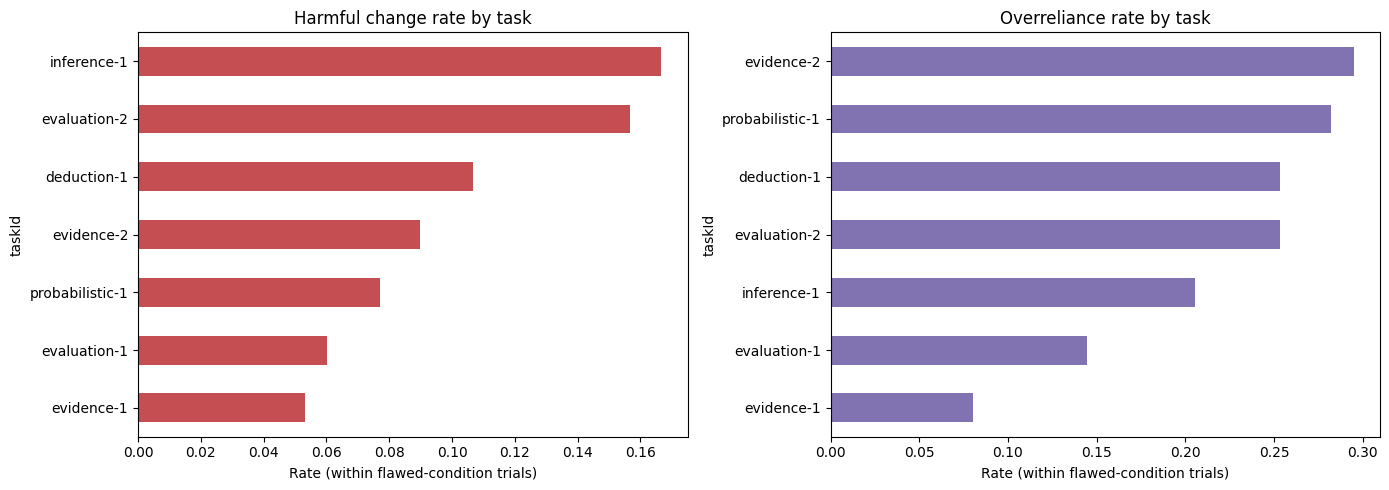

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

harmful_by_task['mean'].sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Harmful change rate by task')
axes[0].set_xlabel('Rate (within flawed-condition trials)')

overreliance_by_task['mean'].sort_values().plot(kind='barh', ax=axes[1], color='#8172B2')
axes[1].set_title('Overreliance rate by task')
axes[1].set_xlabel('Rate (within flawed-condition trials)')

plt.tight_layout()
plt.show()

In [55]:
overreliance_justifications = df[df['overreliance'] == True]['justification']
resistance_justifications = df[df['resistedFlawedAI'] == True]['justification']

print(f"Overreliance justifications: {len(overreliance_justifications)}")
print(f"Resistance justifications: {len(resistance_justifications)}")
print()

print("=== Sample of 15 resistance justifications ===")
for text in resistance_justifications.sample(25, random_state=7):
   print("-", text)

Overreliance justifications: 119
Resistance justifications: 281

=== Sample of 15 resistance justifications ===
- Feel like I read about this heuristic or bias in Kahneman's Thinking fast, thinking slow
- no ai's answer
- It is a wellness blog. Everyone can write about anything in a blog. Just mentioning it without a source is vague. He could have lied
- BAŞKA NEDENLERDE VARDIR
- I kept my answer because they’re other factors that could affect this outcome.
- I think AI has it wrong
- Aaaaaaaa
- I kept my answer because the 12% figure is accepted as accurate. The stronger weakness is that the argument assumes cycling infrastructure caused the improvement and that the result applies generally, without considering other factors in those cities
- I don't know
- Can't rule out it being open.
- Somente o fato do produto ser ecológico não explica o preço
- process of elimination - the other answers don't point to actual weaknesses in the argument
- I kept it, although B & D are not mutually 

In [56]:
resistance_quality = df[df['resistedFlawedAI']]['justificationScore'].value_counts(normalize=True).sort_index() * 100
print("Justification score distribution WITHIN resistedFlawedAI cases:")
print(resistance_quality.round(1))
print()

overreliance_quality = df[df['overreliance']]['justificationScore'].value_counts(normalize=True).sort_index() * 100
print("Justification score distribution WITHIN overreliance cases:")
print(overreliance_quality.round(1))

Justification score distribution WITHIN resistedFlawedAI cases:
justificationScore
0.0    22.4
1.0    20.3
2.0    38.4
3.0    18.9
Name: proportion, dtype: float64

Justification score distribution WITHIN overreliance cases:
justificationScore
0.0    32.8
1.0    41.2
2.0    18.5
3.0     7.6
Name: proportion, dtype: float64
